In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv(r"C:\Users\tinke\Desktop\simulador empresarial\031125dataset.csv", sep=';')

In [3]:
# Revisar los nulos en el df
df.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
age_group    0
dtype: int64

In [4]:
def age_groups(x):

    '''Clasifica el valor de edad numérico dentro de un rango
       ----------
       Parámetro
       x : float - Edad de una persona.
       -------
       Retorna        
       Grupo de edad correspondiente según los siguientes rangos:
       - 'joven' : si la edad es menor o igual a 25
       - 'adulto_joven' : si la edad es menor o igual a 35
       - 'adulto'    : si la edad es menor o igual a 55
       - 'senior' : en el resto de rango de edades'''

    if x <= 25:
        return 'joven'
    elif x <= 35:
        return 'adulto_joven'
    elif x <= 55:
        return 'adulto'
    else:
        return 'senior'
    
# Crear una nueva columna 'age_group' aplicando la función age_groups a la columna 'age'
df['age_group2'] = df['age'].apply(age_groups)

# Verificacion de distribución
(df['age_group2'].value_counts(normalize=True)).round(2)

age_group2
adulto          0.48
adulto_joven    0.35
senior          0.13
joven           0.04
Name: proportion, dtype: float64

In [5]:
def simplify_job(job):

    '''     Clasifica cada valor dentro de una categoría nueva de empleos
       ----------
       Parámetro
       x : object - Profesión de cada cliente.
       -------
       Retorna        
       Etiqueta de nueva catgorización de los empleos:
       - 'profesional' : si los valores son 'management', 'technician', 'administrative', 'services'
       - 'operativo' : si el valor es blue-collar
       - 'autonomo'  : si los valores son 'self-employed', 'entrepreneur'
       - 'jubilado' : si 'retired'
       - no_activo : si los valores son 'unemployed', 'student', 'housemaid'
       - 'otros' : en el resto de los casos
       '''
      
    job = str(job).lower().strip()
    if job in ['management', 'technician', 'administrative', 'services']:
        return 'profesional'
    elif job in ['blue-collar']:
        return 'operativo'
    elif job in ['self-employed', 'entrepreneur']:
         return 'autonomo'
    elif job in ['retired']:
        return 'jubilado'
    elif job in ['unemployed', 'student', 'housemaid']:
        return 'no_activo'
    else:
        return 'otros'

    
# Aplicar la función y crear una columna nueva job_cat
df['job_cat'] = df['job'].apply(simplify_job)

# Verificacion de distribución
(df['job_cat'].value_counts(normalize=True)).round(2)

job_cat
profesional    0.60
operativo      0.18
no_activo      0.09
jubilado       0.07
autonomo       0.07
Name: proportion, dtype: float64

In [6]:
# Education

def simplify_edu(edu):
    edu = str(edu).lower()
    if 'primary' in edu:
        return 'baja'
    elif 'secondary' in edu:
        return 'media'
    else:
        'tertiary' in edu or 'university' in edu
        return 'alta'

df['education_level'] = df['education'].apply(simplify_edu)

# Verificacion de la distribución
(df['education_level'].value_counts(normalize=True)).round(2)

education_level
media    0.52
alta     0.34
baja     0.14
Name: proportion, dtype: float64

In [7]:
# Seleccionar las variables para el clustering
demo_vars = ['age_group2', 'job_cat', 'education_level', 'marital']
df_cat = df[demo_vars].copy()

In [8]:
df_cat

,age_group2,job_cat,education_level,marital
0,senior,profesional,media,married
1,senior,profesional,media,married
2,adulto,profesional,media,married
3,adulto,profesional,media,married
4,adulto,profesional,alta,married
...,...,...,...,...
16157,joven,no_activo,media,single
16158,adulto,profesional,media,divorced
16159,adulto,operativo,media,married
16160,adulto_joven,profesional,alta,single


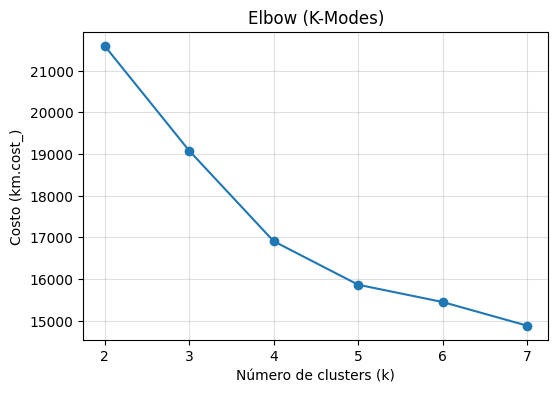

In [9]:
# Metodo de codo (Elbow) para KModes para encontar el número óptimo de clusters
K = range(2, 8)
cost = []

for k in K:
    km = KModes(n_clusters=k, init='Cao', n_init=5, verbose=0, random_state=42) # se pueden usar init= Cao o Huang
    km.fit_predict(df_cat)
    cost.append(km.cost_)

plt.figure(figsize=(6,4))
plt.plot(K, cost, marker='o')
plt.title('Elbow (K-Modes)')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Costo (km.cost_)')
plt.grid(alpha=0.4)
plt.show()


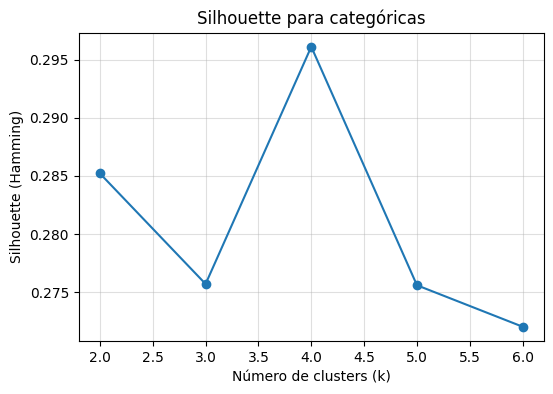

In [10]:
# Codificar variables categóricas como números para calcular silhouette (métrica Hamming), encontrar número óptimo de clusters
df_encoded = df_cat.copy()
for col in df_encoded.columns:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

sil_scores = []
K = range(2, 7)

for k in K:
    km = KModes(n_clusters=k, init='Cao', n_init=5, random_state=42)
    clusters = km.fit_predict(df_cat)
    score = silhouette_score(df_encoded, clusters, metric='hamming')
    sil_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o')
plt.title('Silhouette para categóricas')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette (Hamming)')
plt.grid(alpha=0.4)
plt.show()


## kmode algoritmo

In [11]:
# Definir como número de clusters 5 
kmode = KModes(n_clusters=5, init = "Cao", n_init = 10, verbose=1, random_state=42) # se puede probar con Cao en init o Huang
clusters = kmode.fit_predict(df_cat)
clusters

# Añadir en df original la columna con los clusters generados
df['Cluster'] = clusters 
#df_cat['Cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 1429, cost: 15862.0
Run 1, iteration: 2/100, moves: 155, cost: 15862.0


In [12]:
#demo_vars = ['age_group2', 'job', 'marital', 'education_level']  

cluster_modes = pd.DataFrame(kmode.cluster_centroids_, columns=demo_vars)

cluster_modes.index = [f'Cluster_{i}' for i in range(len(cluster_modes))]

df_cat['Cluster'] = clusters
print(cluster_modes)

             age_group2      job_cat education_level  marital
Cluster_0        adulto  profesional           media  married
Cluster_1  adulto_joven  profesional            alta   single
Cluster_2        adulto    operativo            baja  married
Cluster_3  adulto_joven    operativo           media   single
Cluster_4        senior  profesional            alta  married


In [13]:
# Seleccionar las columnas necesarias para chi2 y cramer's V
cols = ['age_group2', 'job_cat', 'education_level', 'marital', 'loan', 'housing', 'deposit', 'Cluster']

In [14]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):

    '''    Calcula la medida de asociación Cramér's V entre dos variables categóricas,
    utilizando la prueba chi-cuadrado de independencia para calcular la fuerza de asociación entre dos variables categóricas. 
    Cramér's V toma valores entre 0 y 1, donde: 0 -> ninguna asociación, 1 -> asociación perfecta
    ----------
    Parametros
        x : primera variable categórica
        y : segunda variable categórica
    -------
    Returna
    El valor de Cramér's V, entre 0 y 1 : float'''

    
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


# Crear matriz vacía
corr_matrix = pd.DataFrame(index=cols, columns=cols)

# Calcular Cramer's V entre todas las combinaciones
for col1 in cols:
    for col2 in cols:
        corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Convertir a float
corr_matrix = corr_matrix.astype(float)

corr_matrix

,age_group2,job_cat,education_level,marital,loan,housing,deposit,Cluster
age_group2,1.000000,0.380652,0.171775,0.345436,0.060990,0.200635,0.165686,0.519594
job_cat,0.380652,1.000000,0.349315,0.169022,0.113853,0.276860,0.152470,0.380687
education_level,0.171775,0.349315,1.000000,0.132400,0.074917,0.125024,0.100268,0.738073
marital,0.345436,0.169022,0.132400,1.000000,0.065424,0.048532,0.099249,0.494647
loan,0.060990,0.113853,0.074917,0.065424,0.999729,0.076351,0.109833,0.061131
housing,0.200635,0.276860,0.125024,0.048532,0.076351,0.999876,0.203192,0.103766
deposit,0.165686,0.152470,0.100268,0.099249,0.109833,0.203192,0.999876,0.116573
Cluster,0.519594,0.380687,0.738073,0.494647,0.061131,0.103766,0.116573,1.000000


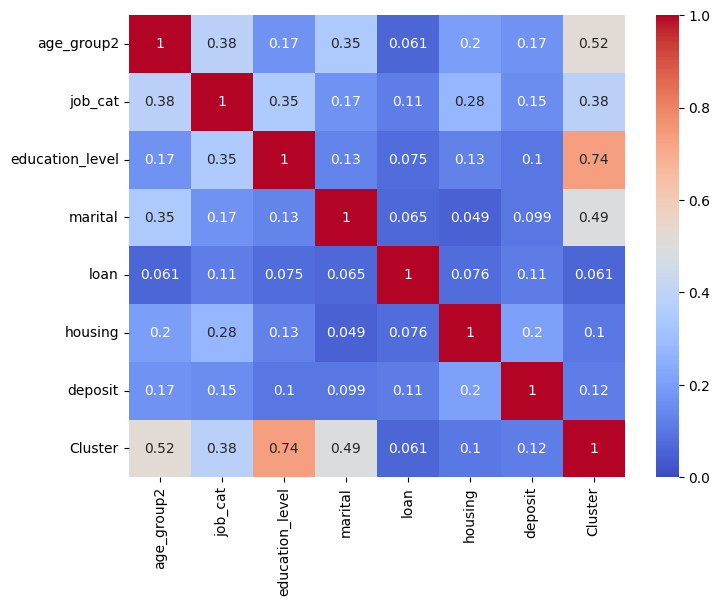

In [15]:
# Hacer Heatmap del corr_matrix anterior
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.show()

<Axes: xlabel='Cluster'>

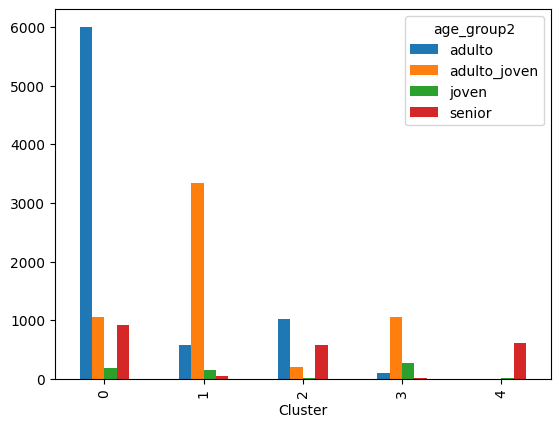

In [16]:
# Gráfico de barras de frequencias de grupo de edad en cada cluster
pd.crosstab(df_cat.Cluster, df_cat.age_group2).plot.bar()

<Axes: xlabel='Cluster'>

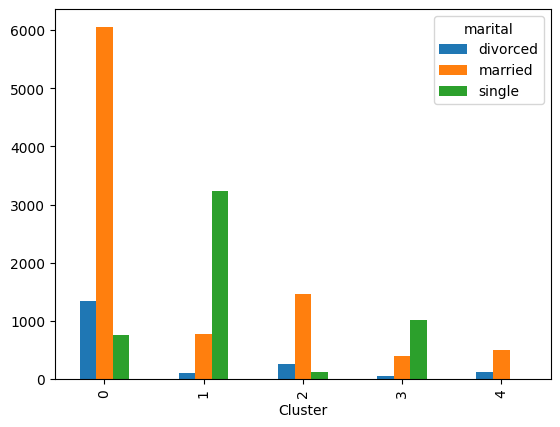

In [17]:
# Gráfico de barras de frequencias de estado civil en cada cluster
pd.crosstab(df_cat.Cluster, df_cat.marital).plot.bar()

<Axes: xlabel='Cluster'>

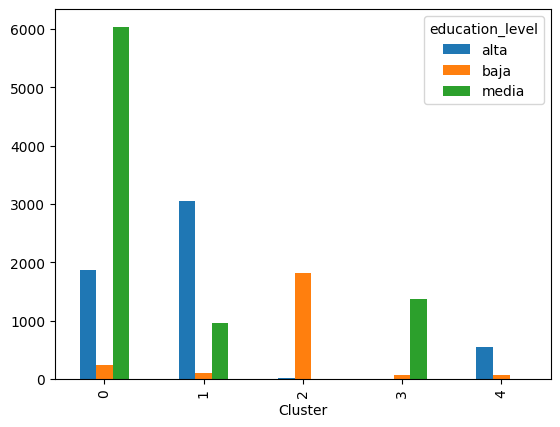

In [18]:
# Gráfico de barras de frequencias de nivel de educación en cada cluster
pd.crosstab(df_cat.Cluster, df_cat.education_level).plot.bar()

<Axes: xlabel='Cluster'>

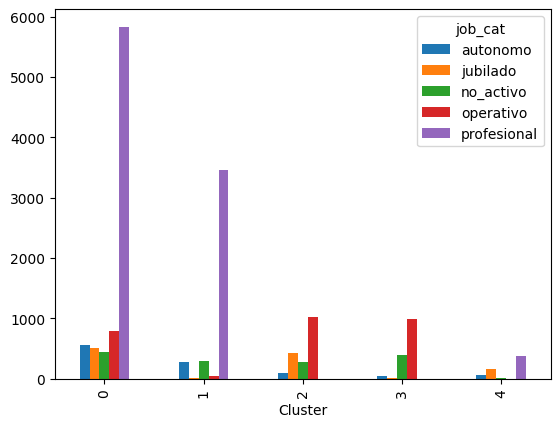

In [19]:
# Gráfico de barras de frequencias de categoría profesional en cada cluster
pd.crosstab(df_cat.Cluster, df_cat.job_cat).plot.bar()

In [20]:
# % de loan 'yes' por cluster
round((pd.crosstab(df['Cluster'], df['loan'], normalize='index') * 100), 1).loc[:, 'yes']

Cluster
0    15.0
1    10.3
2    13.2
3    12.9
4     8.4
Name: yes, dtype: float64

In [22]:
loan_dist = pd.crosstab(df['Cluster'], df['loan'], normalize='index') * 100
housing_dist = pd.crosstab(df['Cluster'], df['housing'], normalize='index') * 100
deposit_dist = pd.crosstab(df['Cluster'], df['deposit'], normalize='index') * 100


In [23]:
print("Loan (yes/no %) por cluster:")
print(loan_dist.round(1))

print("\nHousing (yes/no %) por cluster:")
print(housing_dist.round(1))

print("\nDeposit (yes/no %) por cluster:")
print(deposit_dist.round(1))


Loan (yes/no %) por cluster:
loan       no   yes
Cluster            
0        85.0  15.0
1        89.7  10.3
2        86.8  13.2
3        87.1  12.9
4        91.6   8.4

Housing (yes/no %) por cluster:
housing    no   yes
Cluster            
0        50.7  49.3
1        57.0  43.0
2        53.2  46.8
3        45.3  54.7
4        72.9  27.1

Deposit (yes/no %) por cluster:
deposit    no   yes
Cluster            
0        56.2  43.8
1        46.8  53.2
2        61.0  39.0
3        48.7  51.3
4        36.4  63.6


<Axes: xlabel='Cluster'>

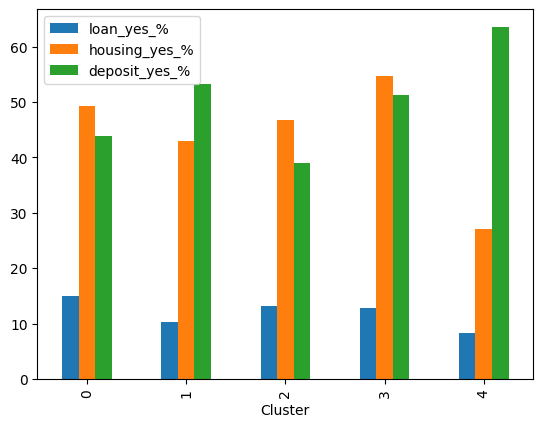

In [29]:
# clusters por porductos y solo con valor 'yes'
loan_yes = (pd.crosstab(df['Cluster'], df['loan'], normalize='index').loc[:,'yes'])* 100
housing_yes = (pd.crosstab(df['Cluster'], df['housing'], normalize='index').loc[:,'yes'] )* 100
deposit_yes = (pd.crosstab(df['Cluster'], df['deposit'], normalize='index').loc[:,'yes'] )* 100

loan_yes.name = 'loan_yes_%'
housing_yes.name = 'housing_yes_%'
deposit_yes.name = 'deposit_yes_%'

# Concat para mostrar todo junto
(pd.concat([loan_yes, housing_yes, deposit_yes], axis=1)).plot.bar()


In [26]:
loan_yes2 = ((pd.crosstab(df['Cluster'], df['loan'], normalize='index').loc[:,'yes'])* 100)
loan_yes2

Cluster
0    14.951552
1    10.328068
2    13.224044
3    12.889813
4     8.373591
Name: yes, dtype: float64

In [27]:
housing_yes2 = ((pd.crosstab(df['Cluster'], df['housing'], normalize='index').loc[:,'yes'])* 100)
housing_yes2

Cluster
0    49.331534
1    42.964763
2    46.830601
3    54.677755
4    27.053140
Name: yes, dtype: float64

In [28]:
deposit_yes2 = ((pd.crosstab(df['Cluster'], df['deposit'], normalize='index').loc[:,'yes'])* 100)
deposit_yes2

Cluster
0    43.848890
1    53.244228
2    38.961749
3    51.282051
4    63.607085
Name: yes, dtype: float64

In [31]:
df.to_csv(r"C:\Users\tinke\Desktop\simulador empresarial\031125dataset.csv",sep=";",index=False)